<a href="https://colab.research.google.com/github/clarachence/prova_11_clara_chence/blob/main/prova_11_clara_chence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. CONFIGURAÇÃO E EXTRAÇÃO


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [30]:
API_KEY = 'VJY5CWLZK2SN5J53'
simbolo = 'NVDA'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={simbolo}&outputsize=compact&apikey={API_KEY}'

dados = requests.get(url).json()
df = pd.DataFrame.from_dict(dados['Time Series (Daily)'], orient='index')
df.index = pd.to_datetime(df.index)
df = df.sort_index().astype(float)
df.columns = ['abertura', 'maxima', 'minima', 'fechamento', 'volume']

print(f"Registros: {len(df)} | Período: {df.index.min().date()} até {df.index.max().date()}")
df.head()

Registros: 100 | Período: 2025-12-09 até 2026-05-04


,abertura,maxima,minima,fechamento,volume
2025-12-09,185.560,185.7167,183.320,184.97,142372621.0
2025-12-10,184.965,185.4800,182.035,183.78,162785370.0
2025-12-11,180.275,181.3200,176.620,180.93,182136641.0
2025-12-12,181.110,182.8200,174.620,175.02,204274918.0
2025-12-15,177.936,178.4150,175.030,176.29,164775636.0


# 2. TRATAMENTO E NORMALIZAÇÃO

### Verificar nulos

In [31]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()

Valores nulos por coluna:
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64


### Verificar duplicatas

In [32]:
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")


Linhas duplicadas: 0


### Estatísticas descritivas


In [33]:
print(f"\nRegistros após limpeza: {len(df)}")
display(df.describe())


Registros após limpeza: 100


,abertura,maxima,minima,fechamento,volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,186.152710,188.641231,183.499778,186.063700,1.701184e+08
std,9.103366,9.246900,8.935428,9.365677,4.453759e+07
min,166.970000,169.450000,164.270000,165.170000,6.552854e+07
25%,179.745000,182.804025,176.560000,180.317500,1.417145e+08
50%,185.070000,187.864950,183.535050,185.005000,1.652848e+08
75%,190.932500,193.012425,186.849975,189.437500,1.873711e+08
max,212.700000,216.825000,208.200000,216.610000,3.608079e+08


### Detectar outliers via IQR

In [34]:
print("\nOutliers detectados por coluna (método IQR):")
for col in ['abertura', 'maxima', 'minima', 'fechamento', 'volume']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"  {col}: {len(outliers)} outliers")


Outliers detectados por coluna (método IQR):
  abertura: 4 outliers
  maxima: 5 outliers
  minima: 3 outliers
  fechamento: 5 outliers
  volume: 4 outliers


# 3. VIZUALIZAÇÃO

## Gráfico de Fechamento


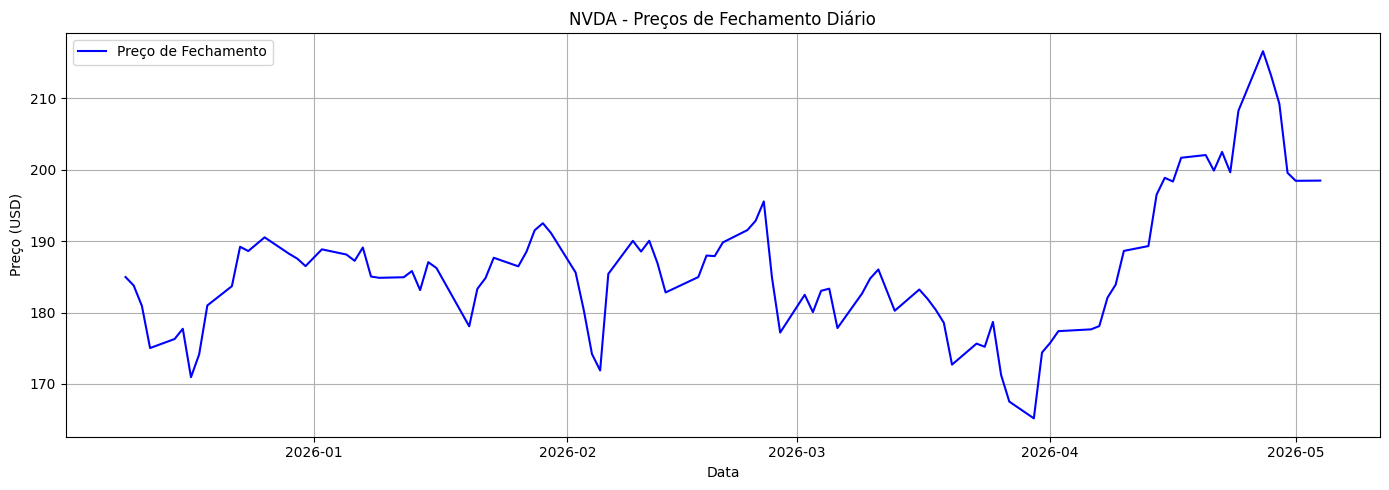

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['fechamento'], label='Preço de Fechamento', color='blue')
plt.title('NVDA - Preços de Fechamento Diário')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de Volume

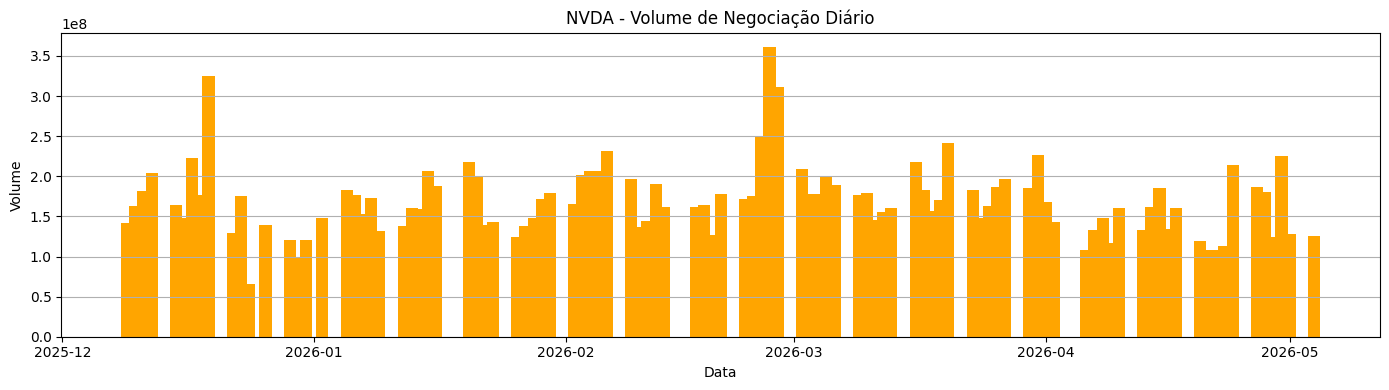

In [39]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['volume'], color='orange', width=1.5)
plt.title('NVDA - Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Correlação entre váriaveis (HeatMap)


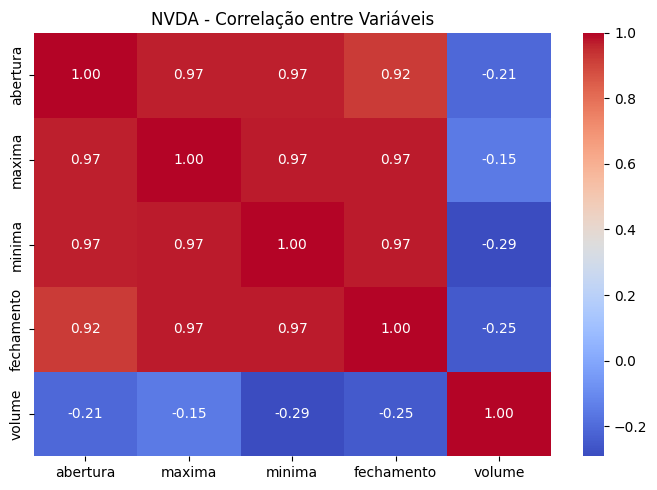

In [38]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['abertura', 'maxima', 'minima', 'fechamento', 'volume']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('NVDA - Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 4. PREPARAÇÃO DOS DADOS

## Target: 1 se a abertura de hoje > máxima de ontem, senão 0

In [40]:
df['alvo'] = np.where(df['abertura'] > df['maxima'].shift(1), 1, 0)

In [41]:
df = df.dropna()

In [42]:
print("Distribuição do alvo:")
print(df['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df['alvo'].mean()*100:.1f}%")

Distribuição do alvo:
alvo
0    83
1    17
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 17.0%


### Gráfico de distribuição do alvo

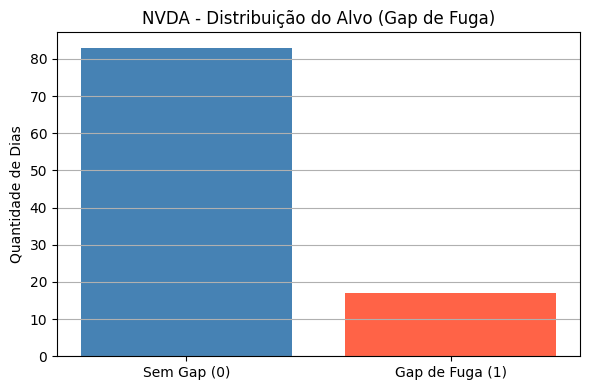

In [43]:
plt.figure(figsize=(6, 4))
contagem = df['alvo'].value_counts()
plt.bar(['Sem Gap (0)', 'Gap de Fuga (1)'], contagem.values, color=['steelblue', 'tomato'])
plt.title('NVDA - Distribuição do Alvo (Gap de Fuga)')
plt.ylabel('Quantidade de Dias')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [44]:
X = df[['abertura', 'maxima', 'minima', 'fechamento', 'volume']]
y = df['alvo']

In [45]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

In [47]:
print(f"X_treino: {X_treino.shape} | X_teste: {X_teste.shape}")
print(f"y_treino: {y_treino.shape} | y_teste: {y_teste.shape}")

X_treino: (70, 5) | X_teste: (30, 5)
y_treino: (70,) | y_teste: (30,)


# 5. MODELAGEM (NAIVE BAYES)

In [48]:
modelo = GaussianNB()
modelo.fit(X_treino, y_treino)

GaussianNB()

In [49]:
y_pred = modelo.predict(X_teste)

In [50]:
print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(y_teste, y_pred, target_names=['Sem Gap (0)', 'Gap de Fuga (1)']))

Acurácia: 66.67%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Sem Gap (0)       0.69      0.95      0.80        21
Gap de Fuga (1)       0.00      0.00      0.00         9

       accuracy                           0.67        30
      macro avg       0.34      0.48      0.40        30
   weighted avg       0.48      0.67      0.56        30



# Análise do Desafio

O modelo apresentou acurácia de 66,67%.

Esse resultado indica um desempenho moderado, melhor que o acaso, mas ainda limitado.

Como a ação NVDA possui movimentos exponenciais e alta volatilidade,
o Naive Bayes tem dificuldade em capturar esses padrões, pois assume independência entre as variáveis.

Em momentos de fortes variações de preço, o modelo tende a errar mais,
mostrando limitação para prever movimentos bruscos do mercado.

In [22]:
print("O modelo apresentou desempenho moderado, com limitações em cenários de alta volatilidade.")

O modelo apresentou desempenho moderado, com limitações em cenários de alta volatilidade.
